# **Reto: Evaluacion del Riesgo Operacional en Canales Electronicos**

En este notebook se desarrolla el reto de riesgo operacional para fallas tecnologicas en canales electronicos. La metodologia sigue la misma linea de los talleres: cargar base, limpiar, crear variables de riesgo, hacer matrices, estimar perdida esperada, calcular OpVaR y dejar una herramienta de auditoria para consultar los eventos de cada celda.

Contexto del caso

Se ha recibido la base de datos historica de Eventos de Riesgo Tecnologico ocurridos en los canales electronicos (App movil, Sucursal Virtual, Cajeros). La mision es transformar estos datos crudos en una herramienta de decision gerencial que permita cuantificar la exposicion economica, la eficacia de los controles actuales y la captura estimada de GEI bajo diferentes niveles de gestion prospectiva del riesgo.


## 1. Carga de librerias

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Cargar el archivo de Excel

El archivo tiene tres hojas: eventos de fallas tecnologicas, tabla de riesgos y tabla de gestion. Uso `header=1` porque en el Excel la primera fila visible es un titulo y la segunda fila trae los nombres reales de las columnas.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Path(r"C:/Users/Usuario/Documents/New project/riesgo_operacional_fallas_tecnologicas.xlsx")


rutas_glob = list(Path("/content").glob("*Riesgo Operacional FallasTecnol*gicas*.xlsx"))
rutas_glob += list(Path(".").glob("*riesgo_operacional_fallas*.xlsx"))

xls = pd.ExcelFile(nxl)
print("Ruta usada:", nxl)
print("Hojas del archivo:", xls.sheet_names)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta usada: /content/5. Riesgo Operacional FallasTecnológicas (1).xlsx
Hojas del archivo: ['Fallas Tecnológicas', 'Riesgos', 'Gestión']


In [9]:
fallas = pd.read_excel(nxl, sheet_name=xls.sheet_names[0], header=1)
riesgos = pd.read_excel(nxl, sheet_name=xls.sheet_names[1], header=1)
gestion = pd.read_excel(nxl, sheet_name=xls.sheet_names[2], header=1)

print("Fallas:", fallas.shape)
print("Riesgos:", riesgos.shape)
print("Gestion:", gestion.shape)

fallas.head()

Fallas: (701, 6)
Riesgos: (5, 7)
Gestion: (5, 5)


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [10]:
riesgos.head()

,Unnamed: 0,Nivel de Impacto,Descripción del Fallo,Impacto en la Operación,Impacto en el Cliente,Impacto Financiero (USD),Frecuencia
0,1,Bajo,"Errores visuales menores, problemas de usabili...","Mínima afectación a las operaciones, impacto e...",Molestia temporal del cliente.,Cientos a miles,Muy Alta
1,2,Medio,"Errores en la interfaz de usuario, fallas en f...","Disminución de la experiencia del usuario, imp...","Molestia del cliente, disminución de la satisf...",Miles a decenas de miles,Alta
2,3,Alto,"Degradación del rendimiento por varias horas, ...","Disminución de la eficiencia operativa, afecta...","Insatisfacción del cliente, pérdida de product...",Decenas de millones a cientos de millones,Media
3,4,Crítico,Degradación severa del rendimiento por más de ...,Disminución drástica de la eficiencia operativ...,"Pérdida de confianza generalizada, insatisfacc...",Cientos de millones a miles de millones,Baja
4,5,Catastrófico,"Caída total del sistema por más de 24 horas, p...","Parálisis completa de las operaciones, incapac...","Pérdida total de confianza, migración masiva d...",Millones a miles de millones,Muy Baja


In [11]:
gestion.head()

,Unnamed: 0,Nivel de Gestión,Actividades de Gestión,Costo (KUSD),Desviación
0,1,Bajo,Capacitación del personal en seguridad informá...,0.012171,0.005710
1,2,Medio,"Gestión de la configuración, seguimiento de mé...",0.037437,0.027454
2,3,Moderado,"Gestión de cambios rigurosa, pruebas de carga ...",0.173067,0.085586
3,4,Alto,Monitoreo en tiempo real de la infraestructura...,0.407991,0.038555
4,5,Crítico,Desarrollo de un plan de recuperación de desas...,0.628350,0.076041


## 3. Limpieza y preparacion de datos

Se renombran columnas para trabajar mas facil y se eliminan espacios en variables de texto. Luego se une la tabla de eventos con la tabla de riesgos usando la descripcion del evento.

In [12]:
fallas.columns = [
    "fecha",
    "transacciones_diarias",
    "valor_transado_millones",
    "transacciones_fallidas",
    "valor_generado_promedio_millones",
    "descripcion_evento"
]

riesgos.columns = [
    "nivel_impacto_num",
    "nivel_impacto",
    "descripcion_evento",
    "impacto_operacion",
    "impacto_cliente",
    "impacto_financiero_usd",
    "frecuencia_teorica"
]

gestion.columns = [
    "nivel_gestion_num",
    "nivel_gestion",
    "actividades_gestion",
    "costo_kusd",
    "desviacion"
]

for df_temp in [fallas, riesgos, gestion]:
    columnas_texto = df_temp.select_dtypes(include=["object"]).columns
    for col in columnas_texto:
        df_temp[col] = df_temp[col].astype(str).str.strip()

XDB = fallas.merge(
    riesgos[["nivel_impacto_num", "nivel_impacto", "descripcion_evento", "impacto_financiero_usd", "frecuencia_teorica"]],
    on="descripcion_evento",
    how="left"
)

XDB.head()

,fecha,transacciones_diarias,valor_transado_millones,transacciones_fallidas,valor_generado_promedio_millones,descripcion_evento,nivel_impacto_num,nivel_impacto,impacto_financiero_usd,frecuencia_teorica
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili...",1,Bajo,Cientos a miles,Muy Alta
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f...",2,Medio,Miles a decenas de miles,Alta
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili...",1,Bajo,Cientos a miles,Muy Alta
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f...",2,Medio,Miles a decenas de miles,Alta
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f...",2,Medio,Miles a decenas de miles,Alta


In [13]:
print("Datos faltantes")
XDB.isnull().sum()

Datos faltantes


,0
fecha,0
transacciones_diarias,0
valor_transado_millones,0
transacciones_fallidas,0
valor_generado_promedio_millones,0
descripcion_evento,0
nivel_impacto_num,0
nivel_impacto,0
impacto_financiero_usd,0
frecuencia_teorica,0


In [14]:
print("Registros duplicados:", XDB.duplicated().sum())
print("Eventos totales:", len(XDB))
print("Transacciones fallidas totales:", XDB["transacciones_fallidas"].sum())

Registros duplicados: 0
Eventos totales: 701
Transacciones fallidas totales: 3332


**Analisis inicial**

La base tiene 701 eventos historicos de fallas tecnologicas. Cada registro trae una fecha, el volumen transado, el numero de transacciones fallidas, el valor promedio generado y la descripcion del evento. Al unir con la matriz de riesgos, cada evento queda asociado con un nivel de impacto: bajo, medio, alto, critico o catastrofico.

## 4. Exploracion preliminar

In [15]:
XDB.describe()

,fecha,transacciones_diarias,valor_transado_millones,transacciones_fallidas,valor_generado_promedio_millones,nivel_impacto_num
count,701,701.000000,701.000000,701.000000,701.000000,701.000000
mean,2010-06-25 06:30:17.974322176,99.158345,24.248679,4.753210,1.929555,1.942939
min,2009-01-01 00:00:00,35.000000,-9.957400,1.000000,0.084200,1.000000
25%,2009-06-25 00:00:00,85.000000,16.851100,2.000000,0.631300,1.000000
50%,2011-01-01 00:00:00,100.000000,24.162000,4.000000,1.224000,2.000000
75%,2011-06-25 00:00:00,115.000000,31.537300,7.000000,2.343900,2.000000
max,2011-12-17 00:00:00,170.000000,59.566900,16.000000,17.312900,5.000000
std,NaN,22.081130,11.598671,2.984796,2.130130,0.991188


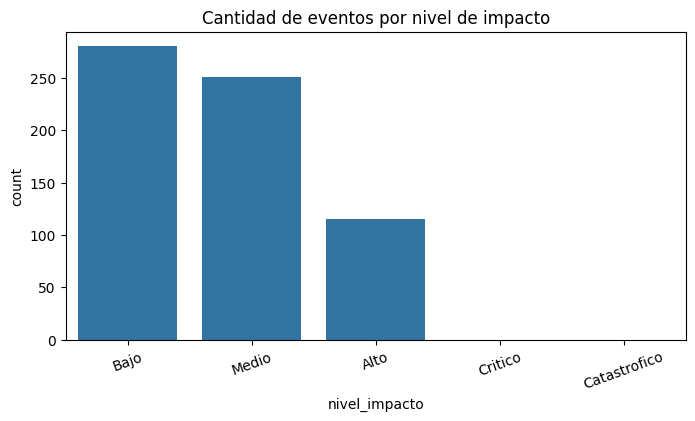

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(data=XDB, x="nivel_impacto", order=["Bajo", "Medio", "Alto", "Critico", "Catastrofico"])
plt.title("Cantidad de eventos por nivel de impacto")
plt.xticks(rotation=20)
plt.show()

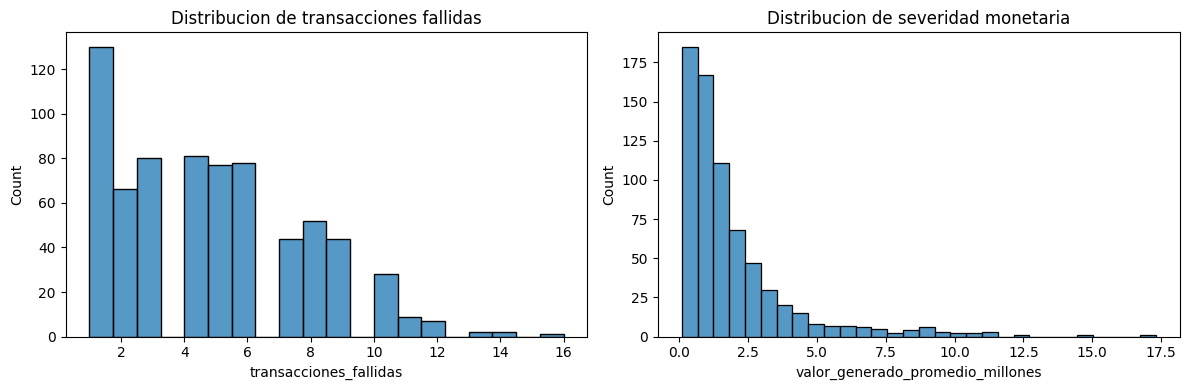

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(XDB["transacciones_fallidas"], bins=20, ax=axes[0])
axes[0].set_title("Distribucion de transacciones fallidas")

sns.histplot(XDB["valor_generado_promedio_millones"], bins=30, ax=axes[1])
axes[1].set_title("Distribucion de severidad monetaria")

plt.tight_layout()
plt.show()

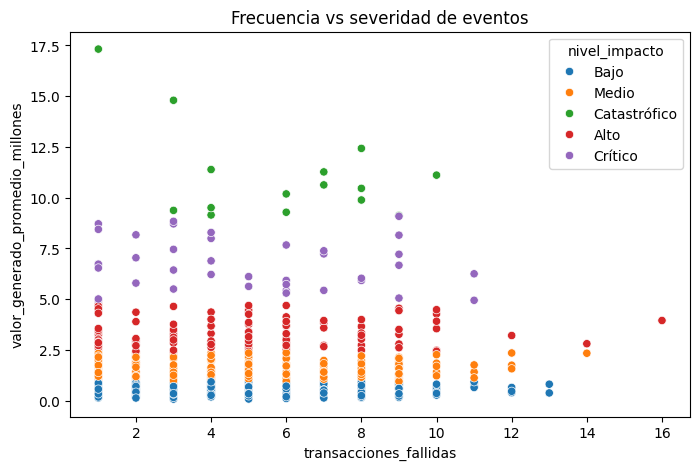

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=XDB,
    x="transacciones_fallidas",
    y="valor_generado_promedio_millones",
    hue="nivel_impacto"
)
plt.title("Frecuencia vs severidad de eventos")
plt.show()

**Lectura preliminar**

La mayoria de eventos se concentran en niveles bajo y medio, pero los eventos criticos y catastroficos tienen mayor severidad monetaria. Esto es importante porque aunque ocurren menos veces, pueden generar perdidas extremas y por eso deben entrar en el calculo de OpVaR.

## 5. Funcion de clusterizacion

Uso la funcion de clusterizacion para crear 5 grupos. La ajusto un poco para que los clusters queden ordenados de menor a mayor y asi poder llamarlos improbable, posible, ocasional, probable y frecuente.

In [19]:
def clusterizacion(xi):
    # Proceso de clusterizacion visto en clase
    np.random.seed(42)
    XC = np.random.choice(xi, size=5)
    XC = np.sort(XC.astype(float))
    nc = np.zeros((len(xi), 1))

    for k in range(len(xi)):
        d = np.abs(XC - xi[k])
        nc[k] = np.argmin(d)
        nc2 = np.int32(nc[k])
        XC[nc2] = (XC[nc2] + xi[k]) / 2

    return XC, nc


def clusterizacion_ordenada(xi):
    XC, nc = clusterizacion(np.array(xi, dtype=float))
    orden = np.argsort(XC)
    mapa = {old: new for new, old in enumerate(orden)}
    nc_ordenada = np.array([mapa[int(v)] for v in nc.ravel()])
    return XC[orden], nc_ordenada

In [20]:
XF = np.array(XDB["transacciones_fallidas"], dtype=float)
Xs = np.array(XDB["valor_generado_promedio_millones"], dtype=float)

XCF, ncf = clusterizacion_ordenada(XF)
XCs, ncs = clusterizacion_ordenada(Xs)

XDB["cluster_frecuencia"] = ncf + 1
XDB["cluster_severidad"] = ncs + 1

labels_frecuencia = {
    1: "Improbable",
    2: "Posible",
    3: "Ocasional",
    4: "Probable",
    5: "Frecuente"
}

labels_severidad = {
    1: "Bajo",
    2: "Medio",
    3: "Alto",
    4: "Critico",
    5: "Catastrofico"
}

XDB["nivel_frecuencia"] = XDB["cluster_frecuencia"].map(labels_frecuencia)
XDB["nivel_severidad"] = XDB["cluster_severidad"].map(labels_severidad)

print("Centros de frecuencia:", XCF)
print("Centros de severidad:", XCs)
XDB[["transacciones_fallidas", "nivel_frecuencia", "valor_generado_promedio_millones", "nivel_severidad"]].head()

Centros de frecuencia: [ 1.07267262  4.40324251  7.88916867  9.72687543 11.89846857]
Centros de severidad: [ 0.37394726  1.16281852  3.80911082  7.25499828 12.98181994]


,transacciones_fallidas,nivel_frecuencia,valor_generado_promedio_millones,nivel_severidad
0,1,Improbable,0.5374,Bajo
1,4,Improbable,1.1978,Alto
2,5,Posible,0.4269,Bajo
3,6,Posible,1.0814,Alto
4,7,Ocasional,1.2105,Alto


## 6. Matrices de frecuencia, severidad y perdidas agregadas

La matriz se arma cruzando frecuencia y severidad. Primero se cuenta el numero de eventos por celda, despues se calcula la severidad promedio y finalmente se estima la perdida agregada.

In [21]:
orden_frecuencia = ["Improbable", "Posible", "Ocasional", "Probable", "Frecuente"]
orden_severidad = ["Bajo", "Medio", "Alto", "Critico", "Catastrofico"]

def ordenar_matriz(tabla):
    return tabla.reindex(index=orden_frecuencia, columns=orden_severidad).fillna(0)

matriz_eventos = pd.crosstab(XDB["nivel_frecuencia"], XDB["nivel_severidad"])
matriz_eventos = ordenar_matriz(matriz_eventos)

matriz_fallas = pd.pivot_table(
    XDB,
    values="transacciones_fallidas",
    index="nivel_frecuencia",
    columns="nivel_severidad",
    aggfunc="sum",
    fill_value=0
)
matriz_fallas = ordenar_matriz(matriz_fallas)

matriz_severidad = pd.pivot_table(
    XDB,
    values="valor_generado_promedio_millones",
    index="nivel_frecuencia",
    columns="nivel_severidad",
    aggfunc="mean",
    fill_value=0
)
matriz_severidad = ordenar_matriz(matriz_severidad)

matriz_eventos

nivel_severidad,Bajo,Medio,Alto,Critico,Catastrofico
nivel_frecuencia,,,,,
Improbable,90,60,38,22,2
Posible,88,48,38,17,8
Ocasional,52,55,28,12,6
Probable,41,36,16,8,8
Frecuente,8,6,9,4,1


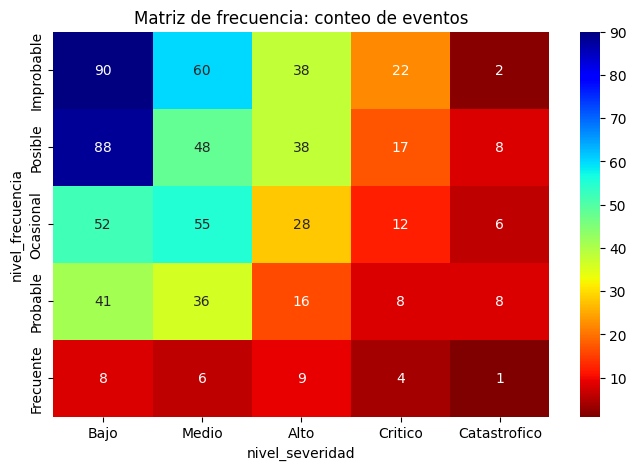

In [22]:
plt.figure(figsize=(8,5))
sns.heatmap(matriz_eventos, annot=True, fmt=".0f", cmap="jet_r")
plt.title("Matriz de frecuencia: conteo de eventos")
plt.show()

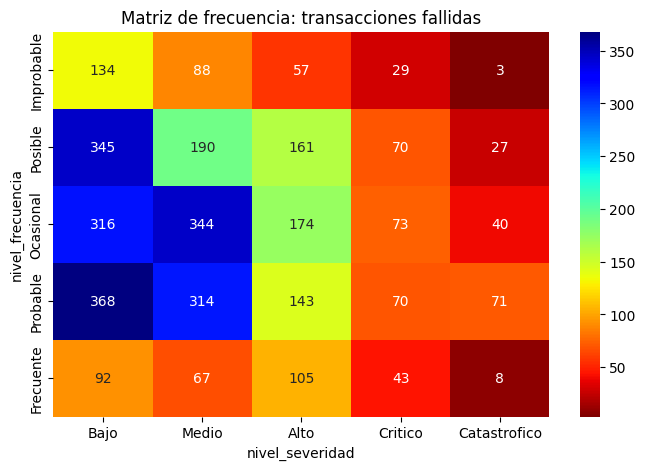

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(matriz_fallas, annot=True, fmt=".0f", cmap="jet_r")
plt.title("Matriz de frecuencia: transacciones fallidas")
plt.show()

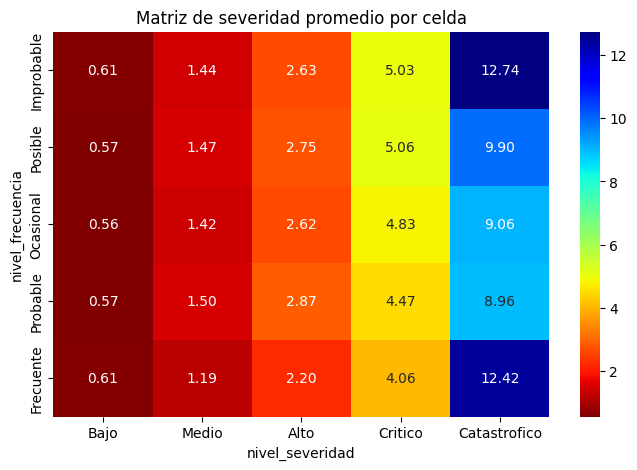

In [24]:
plt.figure(figsize=(8,5))
sns.heatmap(matriz_severidad, annot=True, fmt=".2f", cmap="jet_r")
plt.title("Matriz de severidad promedio por celda")
plt.show()

## 7. Matriz de impacto y matriz de gestion

Se usa la matriz de impacto. La matriz de gestion se construye a partir de un nivel de gestion `NG`. A mayor gestion, menor perdida residual esperada, porque se supone que la organizacion invierte mas recursos para atender riesgos altos.

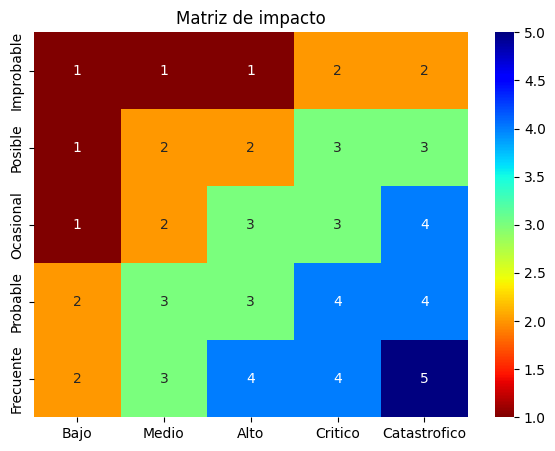

In [25]:
MI = np.array([
    [1, 1, 1, 2, 2],
    [1, 2, 2, 3, 3],
    [1, 2, 3, 3, 4],
    [2, 3, 3, 4, 4],
    [2, 3, 4, 4, 5]
])

plt.figure(figsize=(7,5))
sns.heatmap(MI, annot=True, fmt=".0f", cmap="jet_r", xticklabels=orden_severidad, yticklabels=orden_frecuencia)
plt.title("Matriz de impacto")
plt.show()

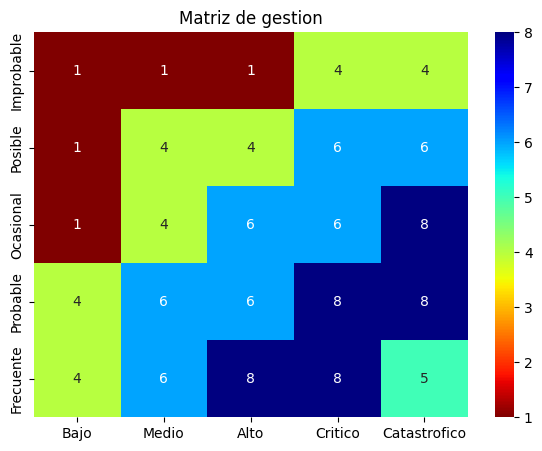

In [26]:
NG = 2  # Nivel de gestion. Se puede cambiar segun el escenario de gestion.

MG = np.copy(MI).astype(float)

for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:
            MG[i, j] = MG[i, j] * NG

plt.figure(figsize=(7,5))
sns.heatmap(MG, annot=True, fmt=".0f", cmap="jet_r", xticklabels=orden_severidad, yticklabels=orden_frecuencia)
plt.title("Matriz de gestion")
plt.show()

## 8. Perdidas no gestionadas y perdidas gestionadas

In [27]:
def obtener_valor_matriz(row, matriz):
    i = int(row["cluster_frecuencia"]) - 1
    j = int(row["cluster_severidad"]) - 1
    return matriz[i, j]

XDB["matriz_impacto"] = XDB.apply(lambda row: obtener_valor_matriz(row, MI), axis=1)
XDB["matriz_gestion"] = XDB.apply(lambda row: obtener_valor_matriz(row, MG), axis=1)

XDB["perdida_no_gestionada"] = (
    XDB["transacciones_fallidas"] *
    XDB["valor_generado_promedio_millones"] *
    XDB["matriz_impacto"]
)

XDB["factor_gestion"] = XDB["matriz_impacto"] / XDB["matriz_gestion"]
XDB["perdida_gestionada"] = XDB["perdida_no_gestionada"] * XDB["factor_gestion"]

XDB[["fecha", "nivel_frecuencia", "nivel_severidad", "matriz_impacto", "matriz_gestion", "perdida_no_gestionada", "perdida_gestionada"]].head()

,fecha,nivel_frecuencia,nivel_severidad,matriz_impacto,matriz_gestion,perdida_no_gestionada,perdida_gestionada
0,2009-01-01,Improbable,Bajo,1,1.0,0.5374,0.53740
1,2009-01-02,Improbable,Alto,1,1.0,4.7912,4.79120
2,2009-01-03,Posible,Bajo,1,1.0,2.1345,2.13450
3,2009-01-04,Posible,Alto,2,4.0,12.9768,6.48840
4,2009-01-05,Ocasional,Alto,3,6.0,25.4205,12.71025


In [28]:
matriz_perdidas_no_gestionadas = pd.pivot_table(
    XDB,
    values="perdida_no_gestionada",
    index="nivel_frecuencia",
    columns="nivel_severidad",
    aggfunc="sum",
    fill_value=0
)
matriz_perdidas_no_gestionadas = ordenar_matriz(matriz_perdidas_no_gestionadas)

matriz_perdidas_gestionadas = pd.pivot_table(
    XDB,
    values="perdida_gestionada",
    index="nivel_frecuencia",
    columns="nivel_severidad",
    aggfunc="sum",
    fill_value=0
)
matriz_perdidas_gestionadas = ordenar_matriz(matriz_perdidas_gestionadas)

matriz_perdidas_no_gestionadas.round(2)

nivel_severidad,Bajo,Medio,Alto,Critico,Catastrofico
nivel_frecuencia,,,,,
Improbable,80.58,128.84,147.47,291.64,67.31
Posible,199.79,561.75,888.52,1084.89,802.92
Ocasional,175.91,968.85,1368.76,1049.87,1450.74
Probable,423.18,1424.71,1237.78,1246.24,2544.01
Frecuente,111.80,240.93,998.06,694.69,496.98


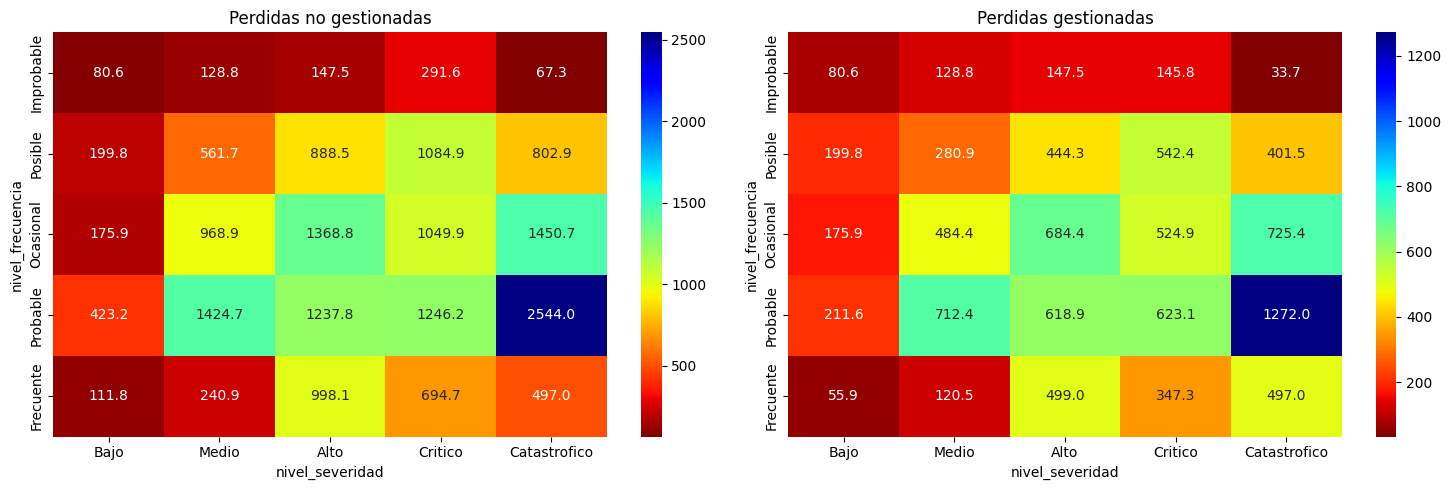

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.heatmap(matriz_perdidas_no_gestionadas, annot=True, fmt=".1f", cmap="jet_r", ax=axes[0])
axes[0].set_title("Perdidas no gestionadas")

sns.heatmap(matriz_perdidas_gestionadas, annot=True, fmt=".1f", cmap="jet_r", ax=axes[1])
axes[1].set_title("Perdidas gestionadas")

plt.tight_layout()
plt.show()

**Analisis de matrices**

La matriz de perdidas muestra que el mayor riesgo no esta solamente en la cantidad de eventos, sino en la combinacion entre frecuencia alta y severidad alta. Las celdas de severidad catastrofica son las que mas pueden mover el resultado, incluso si tienen menos registros. Con gestion, la perdida residual disminuye porque se asignan mas recursos a las celdas de mayor impacto.

## 9. Perdida Esperada y OpVaR 99.9%

La Perdida Esperada se calcula como el promedio de la distribucion de perdidas. El OpVaR al 99.9% se estima con el percentil 99.9 de las perdidas historicas.

In [30]:
PE_no_gestionada = XDB["perdida_no_gestionada"].mean()
PE_gestionada = XDB["perdida_gestionada"].mean()

OpVaR_no_gestionado = XDB["perdida_no_gestionada"].quantile(0.999)
OpVaR_gestionado = XDB["perdida_gestionada"].quantile(0.999)

perdida_total_no_gestionada = XDB["perdida_no_gestionada"].sum()
perdida_total_gestionada = XDB["perdida_gestionada"].sum()
reduccion = (1 - perdida_total_gestionada / perdida_total_no_gestionada) * 100

metricas = pd.DataFrame({
    "Escenario": ["Riesgo Inherente - No gestionado", "Riesgo Residual - Gestionado"],
    "Perdida total": [perdida_total_no_gestionada, perdida_total_gestionada],
    "Perdida Esperada PE": [PE_no_gestionada, PE_gestionada],
    "OpVaR 99.9%": [OpVaR_no_gestionado, OpVaR_gestionado]
})

metricas.round(2)

,Escenario,Perdida total,Perdida Esperada PE,OpVaR 99.9%
0,Riesgo Inherente - No gestionado,18686.22,26.66,460.13
1,Riesgo Residual - Gestionado,9957.89,14.21,304.61


In [31]:
print("Reduccion estimada por gestion:", round(reduccion, 2), "%")

Reduccion estimada por gestion: 46.71 %


<Figure size 800x400 with 0 Axes>

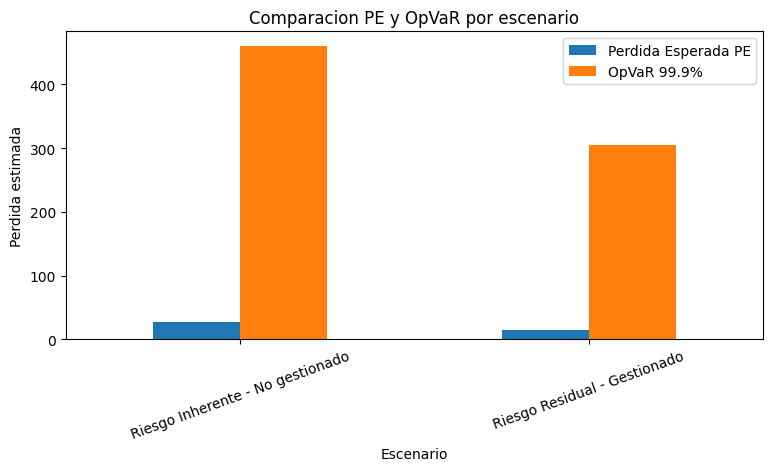

In [32]:
plt.figure(figsize=(8,4))
metricas_plot = metricas.set_index("Escenario")[["Perdida Esperada PE", "OpVaR 99.9%"]]
metricas_plot.plot(kind="bar", figsize=(9,4))
plt.title("Comparacion PE y OpVaR por escenario")
plt.ylabel("Perdida estimada")
plt.xticks(rotation=20)
plt.show()

**Analisis cuantitativo**

En el escenario no gestionado, la perdida total estimada llega aproximadamente a 18,686.22 y la perdida esperada por evento es 26.66. Cuando se incorpora la gestion, la perdida total baja a 9,957.89 y la PE baja a 14.21. Esto representa una reduccion cercana al 46.71%. El OpVaR al 99.9% tambien se reduce, pasando de 460.13 en riesgo inherente a 304.61 en riesgo residual. Esto muestra que la gestion no elimina el riesgo, pero si reduce de forma importante la exposicion economica extrema.

## 10. Eventos mas criticos

In [33]:
XDB.sort_values("perdida_no_gestionada", ascending=False)[[
    "fecha",
    "transacciones_fallidas",
    "valor_generado_promedio_millones",
    "nivel_impacto",
    "nivel_frecuencia",
    "nivel_severidad",
    "perdida_no_gestionada",
    "perdida_gestionada",
    "descripcion_evento"
]].head(10)

,fecha,transacciones_fallidas,valor_generado_promedio_millones,nivel_impacto,nivel_frecuencia,nivel_severidad,perdida_no_gestionada,perdida_gestionada,descripcion_evento
7,2009-01-08,8,12.4245,Catastrófico,Frecuente,Catastrofico,496.9800,496.9800,"Caída total del sistema por más de 24 horas, p..."
252,2009-09-10,10,11.1083,Catastrófico,Probable,Catastrofico,444.3320,222.1660,"Caída total del sistema por más de 24 horas, p..."
298,2009-10-26,8,10.4570,Catastrófico,Probable,Catastrofico,334.6240,167.3120,"Caída total del sistema por más de 24 horas, p..."
218,2009-08-07,9,9.1223,Catastrófico,Probable,Catastrofico,328.4028,164.2014,"Caída total del sistema por más de 24 horas, p..."
383,2011-02-03,9,9.0824,Crítico,Probable,Catastrofico,326.9664,163.4832,Degradación severa del rendimiento por más de ...
410,2011-03-02,8,9.8843,Catastrófico,Probable,Catastrofico,316.2976,158.1488,"Caída total del sistema por más de 24 horas, p..."
202,2009-07-22,7,11.2667,Catastrófico,Ocasional,Catastrofico,315.4676,157.7338,"Caída total del sistema por más de 24 horas, p..."
329,2009-11-26,7,10.6269,Catastrófico,Ocasional,Catastrofico,297.5532,148.7766,"Caída total del sistema por más de 24 horas, p..."
412,2011-03-04,9,8.1529,Crítico,Probable,Catastrofico,293.5044,146.7522,Degradación severa del rendimiento por más de ...
216,2009-08-05,11,6.2513,Crítico,Frecuente,Critico,275.0572,137.5286,Degradación severa del rendimiento por más de ...


## 11. Herramienta de auditoria - filtro dinamico



In [34]:
def auditoria_celda(nivel_frecuencia, nivel_severidad):
    filtro = XDB[
        (XDB["nivel_frecuencia"] == nivel_frecuencia) &
        (XDB["nivel_severidad"] == nivel_severidad)
    ].copy()

    columnas = [
        "fecha",
        "transacciones_diarias",
        "transacciones_fallidas",
        "valor_transado_millones",
        "valor_generado_promedio_millones",
        "nivel_impacto",
        "perdida_no_gestionada",
        "perdida_gestionada",
        "descripcion_evento"
    ]

    return filtro[columnas].sort_values("perdida_no_gestionada", ascending=False)

# Ejemplo: consultar una celda critica
resultado_auditoria = auditoria_celda("Frecuente", "Catastrofico")
print("Eventos encontrados:", len(resultado_auditoria))
resultado_auditoria.head(20)

Eventos encontrados: 1


,fecha,transacciones_diarias,transacciones_fallidas,valor_transado_millones,valor_generado_promedio_millones,nivel_impacto,perdida_no_gestionada,perdida_gestionada,descripcion_evento
7,2009-01-08,90,8,36.4063,12.4245,Catastrófico,496.98,496.98,"Caída total del sistema por más de 24 horas, p..."


In [35]:
# Si se quiere usar de forma manual, cambiar estos dos valores:
nivel_frecuencia_consulta = "Probable"
nivel_severidad_consulta = "Catastrofico"

auditoria_celda(nivel_frecuencia_consulta, nivel_severidad_consulta).head(20)

,fecha,transacciones_diarias,transacciones_fallidas,valor_transado_millones,valor_generado_promedio_millones,nivel_impacto,perdida_no_gestionada,perdida_gestionada,descripcion_evento
252,2009-09-10,105,10,41.0584,11.1083,Catastrófico,444.3320,222.1660,"Caída total del sistema por más de 24 horas, p..."
298,2009-10-26,105,8,22.9937,10.4570,Catastrófico,334.6240,167.3120,"Caída total del sistema por más de 24 horas, p..."
218,2009-08-07,95,9,26.0267,9.1223,Catastrófico,328.4028,164.2014,"Caída total del sistema por más de 24 horas, p..."
383,2011-02-03,130,9,22.5458,9.0824,Crítico,326.9664,163.4832,Degradación severa del rendimiento por más de ...
410,2011-03-02,95,8,24.4764,9.8843,Catastrófico,316.2976,158.1488,"Caída total del sistema por más de 24 horas, p..."
412,2011-03-04,115,9,34.4437,8.1529,Crítico,293.5044,146.7522,Degradación severa del rendimiento por más de ...
250,2009-09-08,120,9,22.0430,7.2127,Crítico,259.6572,129.8286,Degradación severa del rendimiento por más de ...
64,2009-03-06,105,9,38.7241,6.6729,Crítico,240.2244,120.1122,Degradación severa del rendimiento por más de ...


### Filtro interactivo de auditoria

Esta celda crea un filtro dinamico real. Al ejecutarla aparecen dos cuadros seleccionables para escoger la frecuencia y la severidad de la matriz. Luego se presiona el boton y se despliegan automaticamente los eventos que pertenecen a esa celda.

In [36]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    filtro_frecuencia = widgets.Combobox(
        options=orden_frecuencia,
        value="Frecuente",
        description="Frecuencia:",
        placeholder="Escriba o seleccione frecuencia"
    )

    filtro_severidad = widgets.Combobox(
        options=orden_severidad,
        value="Catastrofico",
        description="Severidad:",
        placeholder="Escriba o seleccione severidad"
    )

    numero_eventos = widgets.IntSlider(
        value=20,
        min=5,
        max=100,
        step=5,
        description="Mostrar:",
        continuous_update=False
    )

    boton_consultar = widgets.Button(
        description="Consultar celda",
        button_style="primary"
    )

    salida_filtro = widgets.Output()

    def consultar_celda(b):
        with salida_filtro:
            clear_output()
            resultado = auditoria_celda(filtro_frecuencia.value, filtro_severidad.value)
            print("Celda consultada:", filtro_frecuencia.value, "-", filtro_severidad.value)
            print("Eventos encontrados:", len(resultado))

            if len(resultado) == 0:
                print("No hay eventos para esta combinacion.")
            else:
                print("Perdida no gestionada total:", round(resultado["perdida_no_gestionada"].sum(), 2))
                print("Perdida gestionada total:", round(resultado["perdida_gestionada"].sum(), 2))
                display(resultado.head(numero_eventos.value))

    boton_consultar.on_click(consultar_celda)

    tablero_auditoria = widgets.VBox([
        widgets.HTML("<h3>Filtro dinamico de auditoria por celda de riesgo</h3>"),
        widgets.HBox([filtro_frecuencia, filtro_severidad, numero_eventos]),
        boton_consultar,
        salida_filtro
    ])

    display(tablero_auditoria)
    consultar_celda(None)

except Exception as e:
    print("No se pudo cargar el filtro interactivo con widgets.")
    print("Si estas en Colab, ejecuta: !pip install ipywidgets")
    print(e)

### Filtro por texto como respaldo



In [37]:
# Version manual por cuadro de texto de Python
# Valores permitidos para frecuencia: Improbable, Posible, Ocasional, Probable, Frecuente
# Valores permitidos para severidad: Bajo, Medio, Alto, Critico, Catastrofico

frecuencia_texto = input("Ingrese el nivel de frecuencia: ")
severidad_texto = input("Ingrese el nivel de severidad: ")

resultado_manual = auditoria_celda(frecuencia_texto, severidad_texto)
print("Eventos encontrados:", len(resultado_manual))
resultado_manual.head(20)

Ingrese el nivel de frecuencia: 5
Ingrese el nivel de severidad: 7
Eventos encontrados: 0


,fecha,transacciones_diarias,transacciones_fallidas,valor_transado_millones,valor_generado_promedio_millones,nivel_impacto,perdida_no_gestionada,perdida_gestionada,descripcion_evento


# 13. Gestion prospectiva del riesgo y captura de GEI
**identificar los niveles de captura de gases de efecto invernadero para diferentes niveles de gestion prospectiva del riesgo.**

Para responder esto, se toma la **Distribucion Agregada de Perdidas - LDA**  la LDA se clasifica en 5 niveles de riesgo mediante la misma logica de clusterizacion. Despues se comparan cinco escenarios de gestion prospectiva.

La idea del modelo es la siguiente:

- **Gestion 1:** escenario base, no hay captura financiera adicional.
- **Gestion 2 a 5:** se incrementa la gestion para los riesgos intermedios, reduciendo la perdida gestionada.
- Los riesgos de **nivel 1** se asumen porque son bajos.
- Los riesgos de **nivel 5** se consideran transferibles o catastroficos, por eso no se reducen de la misma forma que los niveles 2, 3 y 4.
- El **valor capturado financiero** es la diferencia entre la perdida base y la perdida gestionada.
- La **captura GEI estimada** se calcula convirtiendo ese valor capturado a toneladas de CO2e con un costo de referencia de 150 unidades monetarias por tonelada.


In [38]:
# Distribucion Agregada de Perdidas - LDA
XDB["LDA"] = XDB["transacciones_fallidas"] * XDB["valor_generado_promedio_millones"]

centros_lda, nclda = clusterizacion_ordenada(XDB["LDA"])
XDB["nivel_riesgo_lda"] = nclda + 1

labels_lda = {
    1: "Esperada baja",
    2: "Esperada media",
    3: "No esperada baja",
    4: "No esperada alta",
    5: "Catastrofica"
}

XDB["categoria_lda"] = XDB["nivel_riesgo_lda"].map(labels_lda)

print("Centros de la LDA:")
print(centros_lda)

XDB[["transacciones_fallidas", "valor_generado_promedio_millones", "LDA", "nivel_riesgo_lda", "categoria_lda"]].head()

Centros de la LDA:
[ 2.92593623  9.92371513 27.70398472 44.94831585 62.82279167]


,transacciones_fallidas,valor_generado_promedio_millones,LDA,nivel_riesgo_lda,categoria_lda
0,1,0.5374,0.5374,1,Esperada baja
1,4,1.1978,4.7912,3,No esperada baja
2,5,0.4269,2.1345,1,Esperada baja
3,6,1.0814,6.4884,3,No esperada baja
4,7,1.2105,8.4735,3,No esperada baja


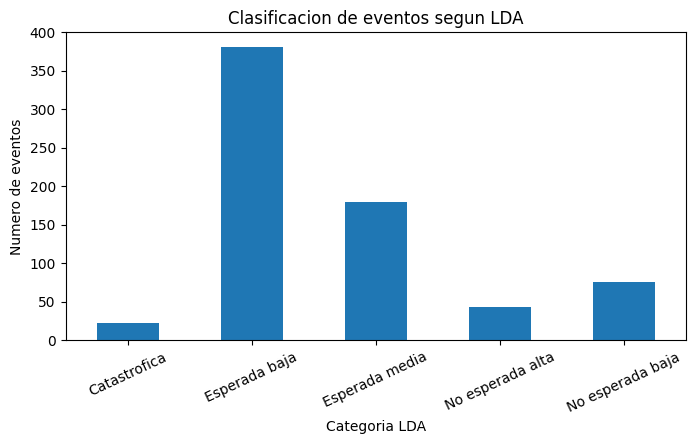

In [39]:
plt.figure(figsize=(8,4))
XDB["categoria_lda"].value_counts().sort_index().plot(kind="bar")
plt.title("Clasificacion de eventos segun LDA")
plt.xlabel("Categoria LDA")
plt.ylabel("Numero de eventos")
plt.xticks(rotation=25)
plt.show()

In [40]:
# Funcion para simular diferentes niveles de gestion prospectiva

def calcular_lda_gestionada(nivel_gestion):
    gestion_aplicada = []

    for nivel_riesgo in XDB["nivel_riesgo_lda"]:
        if nivel_riesgo == 1:
            gestion_aplicada.append(1)
        elif nivel_riesgo == 5:
            gestion_aplicada.append(5)
        else:
            gestion_aplicada.append(nivel_riesgo * nivel_gestion)

    gestion_aplicada = np.array(gestion_aplicada, dtype=float)
    lda_gestionada = XDB["LDA"] * XDB["nivel_riesgo_lda"] / gestion_aplicada

    return lda_gestionada, gestion_aplicada

# Este valor se puede modificar segun el mercado de carbono usado como referencia.
# En el video se menciona 150 como un valor promedio razonable.
precio_tonelada_co2 = 150

resultados_gestion = []
lda_base, gestion_base = calcular_lda_gestionada(1)
perdida_base_total = lda_base.sum()
PE_base = lda_base.mean()
OpVaR_base = lda_base.quantile(0.999)
estados_base = np.where(lda_base <= PE_base, "esperada", np.where(lda_base <= OpVaR_base, "no esperada", "catastrofica"))

for NG in range(1, 6):
    lda_gestionada, gestion_aplicada = calcular_lda_gestionada(NG)
    PE = lda_gestionada.mean()
    OpVaR = lda_gestionada.quantile(0.999)
    UL = OpVaR - PE

    estados = np.where(lda_gestionada <= PE, "esperada", np.where(lda_gestionada <= OpVaR, "no esperada", "catastrofica"))
    eventos_esperados = np.sum(estados == "esperada")
    eventos_no_esperados = np.sum(estados == "no esperada")
    eventos_catastroficos = np.sum(estados == "catastrofica")
    eventos_evitados = np.sum((estados_base != "esperada") & (estados == "esperada")) if NG > 1 else 0

    valor_capturado = perdida_base_total - lda_gestionada.sum()
    captura_gei = valor_capturado / precio_tonelada_co2
    reduccion_pct = (1 - lda_gestionada.sum() / perdida_base_total) * 100

    resultados_gestion.append([
        NG,
        lda_gestionada.sum(),
        PE,
        OpVaR,
        UL,
        eventos_esperados,
        eventos_no_esperados,
        eventos_catastroficos,
        eventos_evitados,
        valor_capturado,
        reduccion_pct,
        captura_gei
    ])

captura_gei_df = pd.DataFrame(resultados_gestion, columns=[
    "Nivel gestion",
    "LDA gestionada total",
    "Perdida esperada PE",
    "OpVaR 99.9%",
    "Perdida no esperada UL",
    "Eventos esperados",
    "Eventos no esperados",
    "Eventos catastroficos",
    "Eventos evitados",
    "Valor capturado financiero",
    "Reduccion perdida %",
    "Captura GEI estimada tCO2e"
])

captura_gei_df.round(2)

,Nivel gestion,LDA gestionada total,Perdida esperada PE,OpVaR 99.9%,Perdida no esperada UL,Eventos esperados,Eventos no esperados,Eventos catastroficos,Eventos evitados,Valor capturado financiero,Reduccion perdida %,Captura GEI estimada tCO2e
0,1,6625.23,9.45,102.9,93.45,502,198,1,0,0.00,0.00,0.00
1,2,4530.24,6.46,102.9,96.44,544,156,1,54,2094.99,31.62,13.97
2,3,3831.91,5.47,102.9,97.44,559,141,1,85,2793.32,42.16,18.62
3,4,3482.74,4.97,102.9,97.93,574,126,1,111,3142.49,47.43,20.95
4,5,3273.24,4.67,102.9,98.23,581,119,1,124,3351.99,50.59,22.35


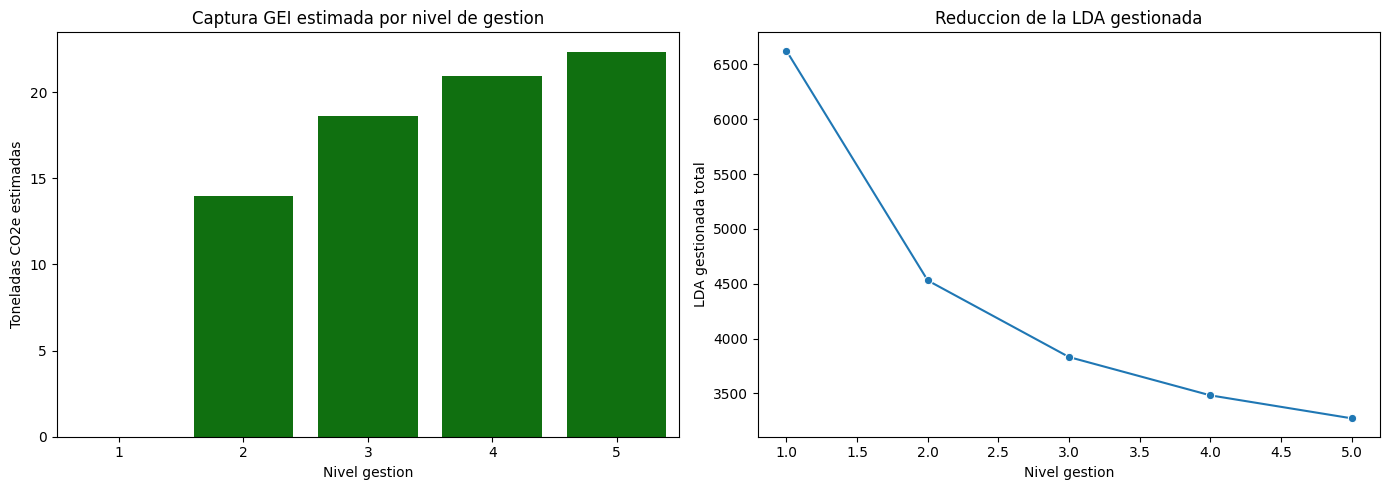

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=captura_gei_df, x="Nivel gestion", y="Captura GEI estimada tCO2e", ax=axes[0], color="green")
axes[0].set_title("Captura GEI estimada por nivel de gestion")
axes[0].set_ylabel("Toneladas CO2e estimadas")

sns.lineplot(data=captura_gei_df, x="Nivel gestion", y="LDA gestionada total", marker="o", ax=axes[1])
axes[1].set_title("Reduccion de la LDA gestionada")
axes[1].set_ylabel("LDA gestionada total")

plt.tight_layout()
plt.show()

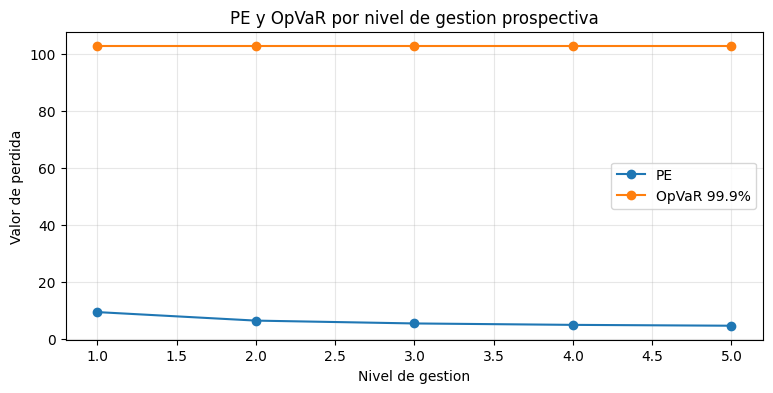

In [42]:
plt.figure(figsize=(9,4))
plt.plot(captura_gei_df["Nivel gestion"], captura_gei_df["Perdida esperada PE"], marker="o", label="PE")
plt.plot(captura_gei_df["Nivel gestion"], captura_gei_df["OpVaR 99.9%"], marker="o", label="OpVaR 99.9%")
plt.title("PE y OpVaR por nivel de gestion prospectiva")
plt.xlabel("Nivel de gestion")
plt.ylabel("Valor de perdida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Respuesta a la pregunta del reto**

Bajo el supuesto de un costo de referencia de **150 unidades monetarias por tonelada de CO2e**, los niveles de captura de GEI aumentan a medida que se incrementa la gestion prospectiva del riesgo. La gestion 1 es el escenario base y no genera captura adicional. Con gestion 2 se obtiene una captura estimada cercana a **13.97 tCO2e**; con gestion 3 aumenta a **18.62 tCO2e**; con gestion 4 llega a **20.95 tCO2e**; y con gestion 5 alcanza aproximadamente **22.35 tCO2e**.

Esto significa que una mayor gestion prospectiva reduce la perdida operacional de las fallas tecnologicas y esa reduccion se interpreta como **valor capturado financiero**. En este modelo, el mayor nivel de gestion genera la mayor captura potencial de GEI, aunque el incremento marginal empieza a ser menor entre los niveles 4 y 5. Por eso, desde una lectura gerencial, la decision no debe ser solamente elegir el nivel maximo, sino comparar la captura adicional con el costo de aplicar esa gestion.


In [43]:
# Guardar resultados especificos del objetivo de captura GEI
salida = Path("resultados_riesgo_operacional")
salida.mkdir(exist_ok=True)

captura_gei_df.to_csv(salida / "captura_gei_por_nivel_gestion.csv", index=False, encoding="utf-8-sig")
XDB.to_csv(salida / "eventos_con_lda_y_categorias_gei.csv", index=False, encoding="utf-8-sig")
print("Resultados de captura GEI guardados en:", salida.resolve())


Resultados de captura GEI guardados en: /content/resultados_riesgo_operacional


# Informe ejecutivo final

El reto buscaba responder cuales son los niveles de captura de gases de efecto invernadero para diferentes niveles de gestion prospectiva del riesgo. Para esto se trabajo la base de eventos de fallas tecnologicas de canales electronicos de una FINTECH, construyendo primero la distribucion agregada de perdidas LDA a partir de la frecuencia de fallas y la severidad monetaria promedio.

La LDA fue clasificada en cinco niveles de riesgo mediante clusterizacion. A partir de esa clasificacion se simularon cinco niveles de gestion prospectiva. El escenario de gestion 1 funciona como base, mientras que los niveles 2 a 5 reducen las perdidas gestionadas en los riesgos intermedios. Esta reduccion se interpreta como valor capturado financiero y luego se convierte en una equivalencia de captura de GEI usando un costo de referencia de 150 por tonelada de CO2e.

Los resultados muestran que la captura estimada pasa de 0 tCO2e en gestion 1 a 13.97 tCO2e en gestion 2, 18.62 tCO2e en gestion 3, 20.95 tCO2e en gestion 4 y 22.35 tCO2e en gestion 5. Esto permite concluir que la gestion prospectiva del riesgo no solamente reduce perdidas operacionales, sino que tambien puede convertirse en un indicador de valor ambiental si se conecta con la captura o compensacion de GEI.


## 12. Guardar resultados

Se guardan las matrices y la base enriquecida para que la empresa pueda revisar los resultados o usarlos en otro tablero.

In [45]:
salida = Path("resultados_riesgo_operacional")
salida.mkdir(exist_ok=True)

XDB.to_csv(salida / "eventos_riesgo_operacional_clasificados.csv", index=False, encoding="utf-8-sig")
matriz_eventos.to_csv(salida / "matriz_frecuencia_eventos.csv", encoding="utf-8-sig")
matriz_severidad.to_csv(salida / "matriz_severidad.csv", encoding="utf-8-sig")
matriz_perdidas_no_gestionadas.to_csv(salida / "matriz_perdidas_no_gestionadas.csv", encoding="utf-8-sig")
matriz_perdidas_gestionadas.to_csv(salida / "matriz_perdidas_gestionadas.csv", encoding="utf-8-sig")
metricas.to_csv(salida / "metricas_pe_opvar.csv", index=False, encoding="utf-8-sig")

print("Archivos guardados en:", salida.resolve())

Archivos guardados en: /content/resultados_riesgo_operacional


:# Conclusión

El analisis de riesgo operacional en canales electronicos muestra que la FINTECH tiene una base historica de 701 eventos asociados con fallas tecnologicas. La primera parte del modelo permite cuantificar frecuencia, severidad, perdidas agregadas, perdida esperada y OpVaR. Sin embargo, el objetivo central  es ir mas alla de la medicion tradicional y responder como cambian los niveles de captura de GEI bajo diferentes niveles de gestion prospectiva del riesgo.

Para responder esta pregunta se construyo la Distribucion Agregada de Perdidas LDA, se clasificaron los eventos en cinco niveles de riesgo y se simularon cinco escenarios de gestion.

La conclusion principal es que una mayor gestion prospectiva reduce la exposicion economica de las fallas tecnologicas y, al mismo tiempo, permite expresar esa reduccion como un indicador de sostenibilidad. El nivel 5 genera la mayor captura estimada, aunque la diferencia entre gestion 4 y 5 es menor que el salto inicial entre gestion 1 y 2. Por eso, la recomendacion gerencial es comparar la captura adicional con el costo de gestion antes de tomar la decision final.
